# Are there Persistening Effects of the Berlin Divison on short-term AirBnB Market in Germany?

In XXX, in Berlin, Germany the XXX divided the city into East-Germany and West Germany.  The wall stood from XXX to XXX.  The characterists of East-Germany are XXX. The characteristis of West-Germany are XXX. Today, the split 


Aayush Dhakal, Nicols Pazos, Sharanya Bhattacharjee, and Melissa Carson
ACE 592,  2025

[**Data Background**](#toc1_1)

The Data is from Inside AirBnB, https://insideairbnb.com/berlin/

Inside AirBnB Description: "Inside Airbnb is a mission driven project that provides data and advocacy about Airbnb's impact on residential communities. We work towards a vision where communities are empowered with data and information to understand, decide and control the role of renting residential homes to tourists...Inside Airbnb is mission-driven and supports residents and activists who are organising to protect their communities from the negative effects of short-term rentals. Inside Airbnb deeply believes in the power of community, in sharing resources and celebrating successes."

Documentation of Data Assumptions, https://insideairbnb.com/data-assumptions/

Summary of relevant Data Assumptions and Limitations:
 - "Location information for listings are anonymized by Airbnb.
In practice, this means the location for a listing on the map, or in the data will be from 0-450 feet (150 metres) of the actual address.
Listings in the same building are anonymized by Airbnb individually, and therefore may appear "scattered" in the area surrounding the actual address."
 - "Neighbourhood names for each listing are compiled by comparing the listing's geographic coordinates with a city's definition of neighbourhoods. Airbnb neighbourhood names are not used because of their inaccuracies."
- "The Airbnb calendar for a listing does not differentiate between a booked night vs an unavailable night, therefore these bookings have been counted as 'unavailable'. This serves to understate the Availability metric because popular listings will be "booked" rather than being 'blacked out' by a host."
- "One of the biggest issues with Airbnb is whether hosts are renting out residential properties permanently as hotels, as opposed to sharing the primary residence in which they live 'occasionally'. An occupancy model can be used to estimate how often an Airbnb listing is being rented out, and also approximate a listing's income."
- "A Review Rate of 50% is used to convert reviews to estimated bookings."
- "An average length of stay, where avaialble, is configured for each city, and this, multiplied by the estimated bookings for each listing over a period gives the occupancy rate"



[**Data Preparation**](#toc1_1)


In [1]:
# I think this is everything we used on HW  + HW 1 + HW 2
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas
import pyproj
import rasterio
import rasterstats
import json
from rasterio.mask import mask
from rasterio.plot import show
import matplotlib.colors as pltc
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
from sklearn.feature_extraction.text import CountVectorizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
import string
from nltk.corpus import stopwords
import string
import emoji
from datetime import timedelta


In [2]:
### I think this will work for mac users, dont know for windows..
data_dir= "~/Library/CloudStorage/Box-Box/Data Science Project/"


In [3]:
listings_df = pd.read_csv(data_dir+"listings_full/listings.csv")
listings_df.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2084992,https://www.airbnb.com/rooms/2084992,20241221052002,2024-12-21,previous scrape,"Nice and cozy apartment in Kreuzberg, Graefekiez",Our cosy two room Apartment (70qm) in a vibrat...,"The apartment is situated on Fichtestrasse, wh...",https://a0.muscache.com/pictures/c4f2a8a8-34fa...,6302373,...,5.00,4.64,4.82,NaN,f,1,1,0,0,0.09
1,1123383729460847373,https://www.airbnb.com/rooms/1123383729460847373,20241221052002,2024-12-21,city scrape,Furnished room in well equipped serviced apart...,Room in an apartment available. Apartment has ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,206488801,...,NaN,NaN,NaN,NaN,f,3,1,2,0,NaN
2,1205255838613758737,https://www.airbnb.com/rooms/1205255838613758737,20241221052002,2024-12-21,city scrape,Luxurous game room with private bath in X-Berg,Cozy private room in Berlin Mitte with private...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,50009901,...,4.97,4.94,4.94,01/Z/AZ/017416-24,f,1,0,1,0,9.53
3,8164759,https://www.airbnb.com/rooms/8164759,20241221052002,2024-12-21,previous scrape,Beautiful single-room studio,Experience the “real Berlin” in our small and ...,In the area you can find lots of affordable ba...,https://a0.muscache.com/pictures/103988560/a5d...,42115726,...,5.00,3.00,3.00,NaN,f,1,1,0,0,0.01
4,18836877,https://www.airbnb.com/rooms/18836877,20241221052002,2024-12-21,previous scrape,Unterkunft zentral in Berlin,"The accommodation has 3 rooms, however, is onl...",NaN,https://a0.muscache.com/pictures/452bf022-c9a9...,131184702,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN


In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point 


In [5]:
berlin = geopandas.read_file(data_dir+"/berlin.json")

In [6]:

# Convert Airbnb data to GeoDataFrame
geometry = [Point(xy) for xy in zip(listings_df['longitude'], listings_df['latitude'])]
airbnb_gdf = gpd.GeoDataFrame(listings_df, geometry=geometry, crs="EPSG:4326")

# Reproject Germany map to match Airbnb CRS if necessary
if berlin.crs != berlin.crs:
    berlin = berlin.to_crs(airbnb_gdf.crs)


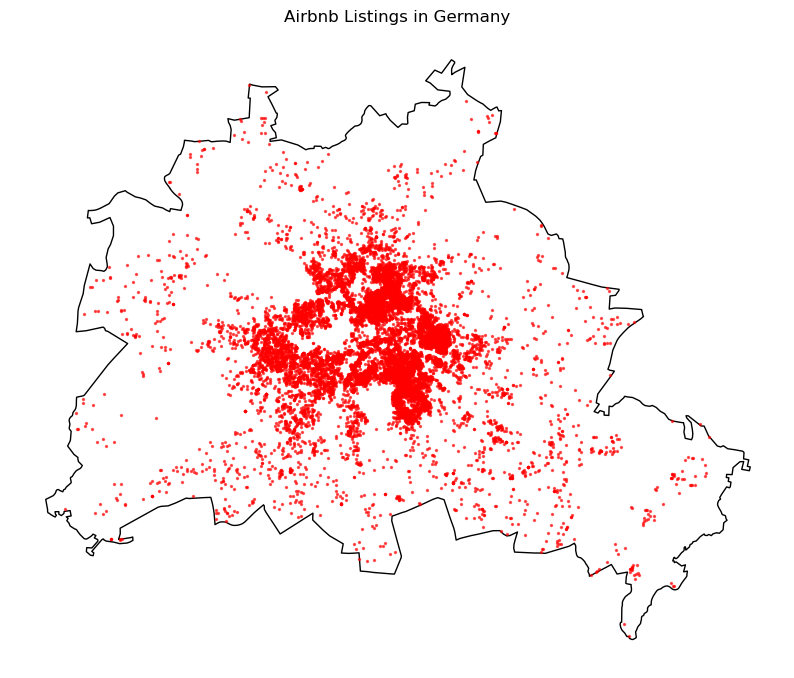

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
berlin.plot(ax=ax, color='white', edgecolor='black')
airbnb_gdf.plot(ax=ax, color='red', markersize=2, alpha=0.6)
plt.title("Airbnb Listings in Germany")
plt.axis("off")
plt.show()

In [8]:
berlin_wall = geopandas.read_file(data_dir+"/berlin_wall.json")

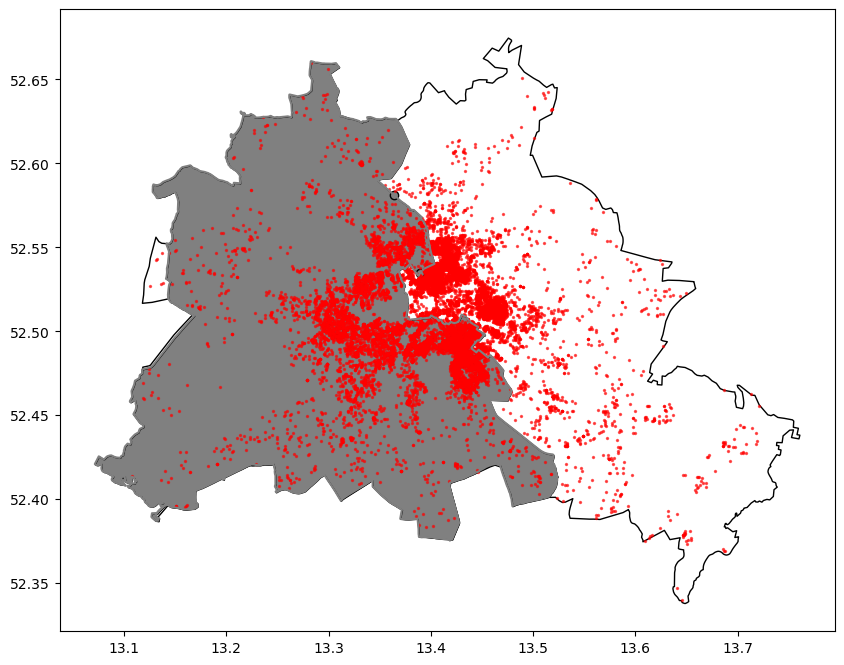

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
berlin.plot(ax=ax, color='white', edgecolor='black')
berlin_wall.plot(ax=ax, color='grey', edgecolor='black')
airbnb_gdf.plot(ax=ax, color='red', markersize=2, alpha=0.6)

plt.show()

In [10]:
if berlin_wall.crs != berlin.crs:
    berlin_wall = berlin_wall.to_crs(berlin.crs)

# Subtract West Berlin from Berlin to get East Berlin
west_berlin_shape = berlin_wall.unary_union
berlin_shape = berlin.unary_union
east_berlin_shape = berlin_shape.difference(west_berlin_shape)

# Convert to GeoDataFrame
east_berlin_gdf = gpd.GeoDataFrame(geometry=[east_berlin_shape], crs=berlin.crs)

/var/folders/p9/fmzq3dpx4vz5c6jcmsdcn_n80000gn/T/ipykernel_91298/207473935.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  west_berlin_shape = berlin_wall.unary_union
/var/folders/p9/fmzq3dpx4vz5c6jcmsdcn_n80000gn/T/ipykernel_91298/207473935.py:6: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  berlin_shape = berlin.unary_union


In [11]:
east_parts = east_berlin_gdf.explode(index_parts=True).reset_index(drop=True)
largest_geom = east_parts.loc[east_parts.area.idxmax()]
east_berlin = gpd.GeoDataFrame(geometry=[largest_geom.geometry], crs=east_parts.crs)

wall_parts = berlin_wall.explode(index_parts=True).reset_index(drop=True)
largest_wall = wall_parts.loc[wall_parts.area.idxmax()]
west_berlin = gpd.GeoDataFrame(geometry=[largest_wall.geometry], crs=wall_parts.crs)


/var/folders/p9/fmzq3dpx4vz5c6jcmsdcn_n80000gn/T/ipykernel_91298/1538850594.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  largest_geom = east_parts.loc[east_parts.area.idxmax()]
/var/folders/p9/fmzq3dpx4vz5c6jcmsdcn_n80000gn/T/ipykernel_91298/1538850594.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  largest_wall = wall_parts.loc[wall_parts.area.idxmax()]


In [12]:
from shapely.geometry import LineString, MultiLineString, GeometryCollection

east_geom = east_berlin.geometry.iloc[0]
west_geom = west_berlin.geometry.iloc[0]
# Assume this from intersection
intersection = east_geom.boundary.intersection(west_geom.boundary)

# If it's a GeometryCollection, extract only the line-like geometries
if isinstance(intersection, GeometryCollection):
    line_parts = [geom for geom in intersection.geoms if isinstance(geom, (LineString, MultiLineString))]
    # Merge to MultiLineString if needed
    if len(line_parts) > 1:
        dividing_line = MultiLineString(line_parts)
    elif len(line_parts) == 1:
        dividing_line = line_parts[0]
    else:
        dividing_line = None  # No valid line
else:
    dividing_line = intersection  # Already a line


dividing_line_gdf = gpd.GeoDataFrame(geometry=[dividing_line], crs=east_berlin.crs)


In [13]:
dividing_line_gdf.to_file("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/dividing_line.json", driver="GeoJSON")
east_berlin.to_file("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/east_berlin.json", driver="GeoJSON")
west_berlin.to_file("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/west_berlin.json", driver="GeoJSON")

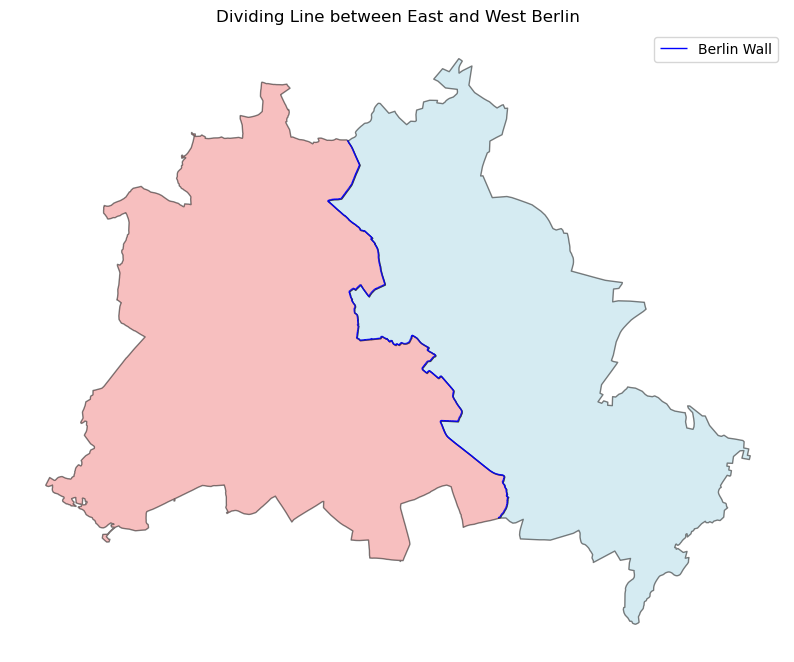

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))
east_berlin.plot(ax=ax, facecolor='lightblue', edgecolor='black', alpha=0.5)
west_berlin.plot(ax=ax, facecolor='lightcoral', edgecolor='black', alpha=0.5)
dividing_line_gdf.plot(ax=ax, color='blue', linewidth=1, label='Berlin Wall')

plt.title("Dividing Line between East and West Berlin")
plt.axis("off")
plt.legend()
plt.show()


In [15]:
assert airbnb_gdf.crs == east_berlin.crs == berlin_wall.crs

#  Define masks for each region
in_east = airbnb_gdf.within(east_berlin.geometry.iloc[0])
in_west = airbnb_gdf.within(west_berlin.geometry.iloc[0])

# Assign categories
airbnb_gdf["region"] = "Unknown"  # Default
airbnb_gdf.loc[in_east, "region"] = "East Berlin"
airbnb_gdf.loc[in_west, "region"] = "West Berlin"
airbnb_gdf.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry,region
0,2084992,https://www.airbnb.com/rooms/2084992,20241221052002,2024-12-21,previous scrape,"Nice and cozy apartment in Kreuzberg, Graefekiez",Our cosy two room Apartment (70qm) in a vibrat...,"The apartment is situated on Fichtestrasse, wh...",https://a0.muscache.com/pictures/c4f2a8a8-34fa...,6302373,...,4.82,NaN,f,1,1,0,0,0.09,POINT (13.4148 52.48855),West Berlin
1,1123383729460847373,https://www.airbnb.com/rooms/1123383729460847373,20241221052002,2024-12-21,city scrape,Furnished room in well equipped serviced apart...,Room in an apartment available. Apartment has ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,206488801,...,NaN,NaN,f,3,1,2,0,NaN,POINT (13.35 52.5609),West Berlin
2,1205255838613758737,https://www.airbnb.com/rooms/1205255838613758737,20241221052002,2024-12-21,city scrape,Luxurous game room with private bath in X-Berg,Cozy private room in Berlin Mitte with private...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,50009901,...,4.94,01/Z/AZ/017416-24,f,1,0,1,0,9.53,POINT (13.41532 52.50481),East Berlin
3,8164759,https://www.airbnb.com/rooms/8164759,20241221052002,2024-12-21,previous scrape,Beautiful single-room studio,Experience the “real Berlin” in our small and ...,In the area you can find lots of affordable ba...,https://a0.muscache.com/pictures/103988560/a5d...,42115726,...,3.00,NaN,f,1,1,0,0,0.01,POINT (13.35778 52.54824),West Berlin
4,18836877,https://www.airbnb.com/rooms/18836877,20241221052002,2024-12-21,previous scrape,Unterkunft zentral in Berlin,"The accommodation has 3 rooms, however, is onl...",NaN,https://a0.muscache.com/pictures/452bf022-c9a9...,131184702,...,NaN,NaN,f,1,1,0,0,NaN,POINT (13.42049 52.53647),East Berlin


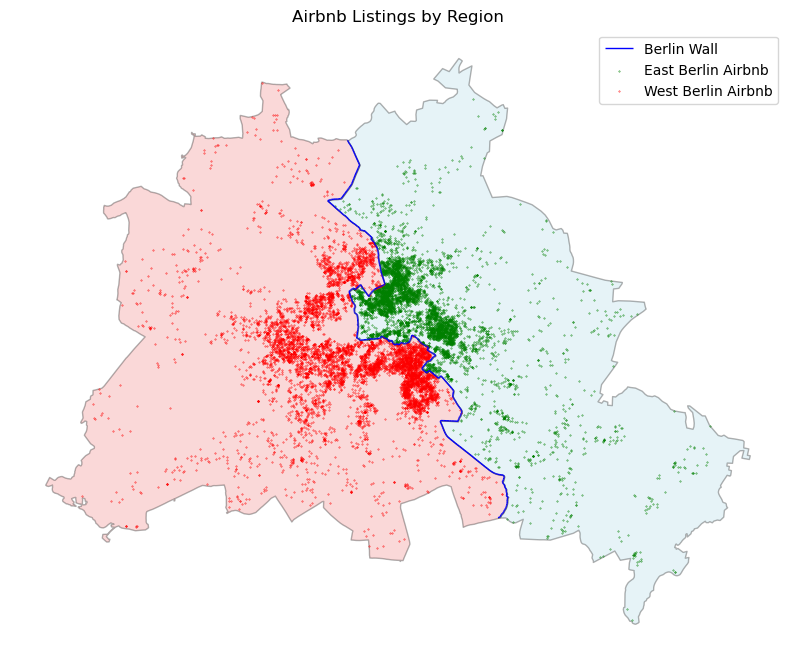

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
east_berlin.plot(ax=ax, facecolor='lightblue', edgecolor='black', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='lightcoral', edgecolor='black', alpha=0.3)
dividing_line_gdf.plot(ax=ax, color='blue', linewidth=1, label='Berlin Wall')

airbnb_gdf[airbnb_gdf["region"] == "East Berlin"].plot(ax=ax, color='green', markersize=.1, label='East Berlin Airbnb')
airbnb_gdf[airbnb_gdf["region"] == "West Berlin"].plot(ax=ax, color='red', markersize=0.1, label='West Berlin Airbnb')

plt.title("Airbnb Listings by Region")
plt.axis("off")
plt.legend()
plt.show()

In [17]:
airbnb_proj = airbnb_gdf.to_crs(epsg=32633)
wall_proj = dividing_line_gdf.to_crs(epsg=32633)

# Get the wall geometry (assuming one geometry)
wall_geom = wall_proj.geometry.iloc[0]

# Calculate distance to the wall line for each Airbnb point
airbnb_proj["distance_to_wall_m"] = airbnb_proj.geometry.distance(wall_geom)
airbnb_gdf["distance_to_wall_m"] = airbnb_proj.geometry.distance(wall_geom)


In [18]:
# Keep only Airbnb listings within 1 km (1,000 meters) of the wall
near_wall = airbnb_proj[airbnb_proj["distance_to_wall_m"] <= 1000]
east_near_wall = near_wall[near_wall["region"] == "East Berlin"]
west_near_wall = near_wall[near_wall["region"] == "West Berlin"]

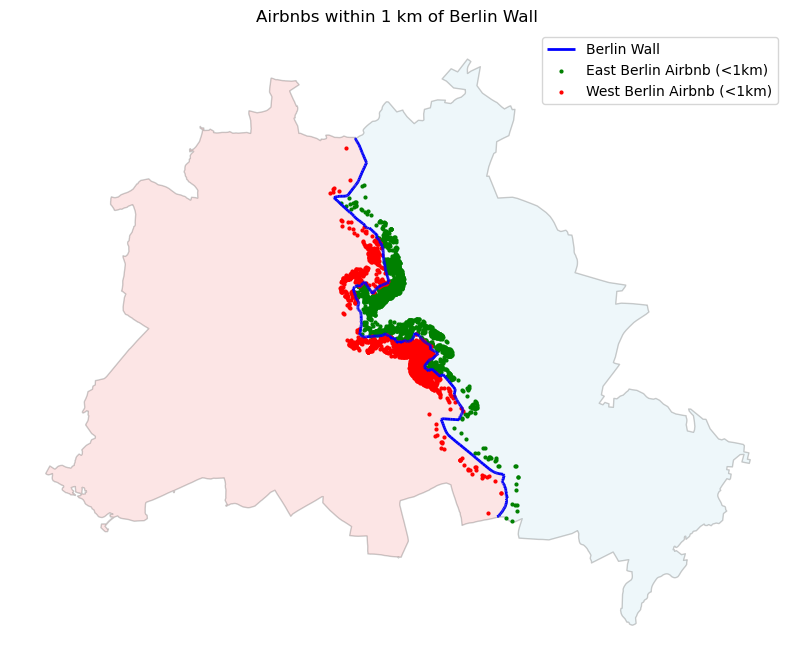

In [19]:

fig, ax = plt.subplots(figsize=(10, 10))

east_berlin.to_crs(epsg=32633).plot(ax=ax, facecolor='lightblue', alpha=0.2, edgecolor='black')
west_berlin.to_crs(epsg=32633).plot(ax=ax, facecolor='lightcoral', alpha=0.2, edgecolor='black')
wall_proj.plot(ax=ax, color='blue', linewidth=2, label='Berlin Wall')

# Airbnb points
east_near_wall.plot(ax=ax, color='green', markersize=4, label='East Berlin Airbnb (<1km)')
west_near_wall.plot(ax=ax, color='red', markersize=4, label='West Berlin Airbnb (<1km)')

plt.title("Airbnbs within 1 km of Berlin Wall")
plt.axis("off")
plt.legend()
plt.show()


In [20]:
borough = geopandas.read_file(data_dir+"/boroughs.geojson")
borough

,OBJECTID,Gemeinde_n,Gemeinde_s,Land_name,Land_schlu,Schluessel,geometry
0,1,Reinickendorf,012,Berlin,11,11000012,"POLYGON ((13.32074 52.6266, 13.32104 52.62658,..."
1,2,Charlottenburg-Wilmersdorf,004,Berlin,11,11000004,"POLYGON ((13.32111 52.52446, 13.32137 52.52452..."
2,3,Treptow-Köpenick,009,Berlin,11,11000009,"POLYGON ((13.57925 52.39083, 13.57894 52.39078..."
3,4,Pankow,003,Berlin,11,11000003,"MULTIPOLYGON (((13.50481 52.6196, 13.50484 52...."
4,5,Neukölln,008,Berlin,11,11000008,"POLYGON ((13.45832 52.48569, 13.45856 52.48552..."
5,6,Lichtenberg,011,Berlin,11,11000011,"POLYGON ((13.52316 52.47424, 13.52289 52.47444..."
6,7,Marzahn-Hellersdorf,010,Berlin,11,11000010,"POLYGON ((13.61317 52.47213, 13.61298 52.47197..."
7,8,Spandau,005,Berlin,11,11000005,"POLYGON ((13.23119 52.56124, 13.23135 52.56112..."
8,9,Steglitz-Zehlendorf,006,Berlin,11,11000006,"POLYGON ((13.31952 52.46699, 13.31984 52.46698..."
9,10,Mitte,001,Berlin,11,11000001,"POLYGON ((13.37721 52.56091, 13.37727 52.56114..."


In [21]:
airbnb_gdf.crs == borough.crs 

True

In [22]:
# Assign default category
airbnb_gdf["borough"] = "Unknown"

# Loop through each borough geometry and assign label
for i, name in enumerate(borough["Gemeinde_n"]):
    mask = airbnb_gdf.within(borough.geometry.iloc[i])
    airbnb_gdf.loc[mask, "borough"] = name

airbnb_gdf.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,geometry,region,distance_to_wall_m,borough
0,2084992,https://www.airbnb.com/rooms/2084992,20241221052002,2024-12-21,previous scrape,"Nice and cozy apartment in Kreuzberg, Graefekiez",Our cosy two room Apartment (70qm) in a vibrat...,"The apartment is situated on Fichtestrasse, wh...",https://a0.muscache.com/pictures/c4f2a8a8-34fa...,6302373,...,f,1,1,0,0,0.09,POINT (13.4148 52.48855),West Berlin,1712.804099,Friedrichshain-Kreuzberg
1,1123383729460847373,https://www.airbnb.com/rooms/1123383729460847373,20241221052002,2024-12-21,city scrape,Furnished room in well equipped serviced apart...,Room in an apartment available. Apartment has ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,206488801,...,f,3,1,2,0,NaN,POINT (13.35 52.5609),West Berlin,2317.251855,Mitte
2,1205255838613758737,https://www.airbnb.com/rooms/1205255838613758737,20241221052002,2024-12-21,city scrape,Luxurous game room with private bath in X-Berg,Cozy private room in Berlin Mitte with private...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,50009901,...,f,1,0,1,0,9.53,POINT (13.41532 52.50481),East Berlin,0.942921,Mitte
3,8164759,https://www.airbnb.com/rooms/8164759,20241221052002,2024-12-21,previous scrape,Beautiful single-room studio,Experience the “real Berlin” in our small and ...,In the area you can find lots of affordable ba...,https://a0.muscache.com/pictures/103988560/a5d...,42115726,...,f,1,1,0,0,0.01,POINT (13.35778 52.54824),West Berlin,1506.226004,Mitte
4,18836877,https://www.airbnb.com/rooms/18836877,20241221052002,2024-12-21,previous scrape,Unterkunft zentral in Berlin,"The accommodation has 3 rooms, however, is onl...",NaN,https://a0.muscache.com/pictures/452bf022-c9a9...,131184702,...,f,1,1,0,0,NaN,POINT (13.42049 52.53647),East Berlin,1222.266153,Pankow


"airbnb_proj" data frame has distance to wall in meters 

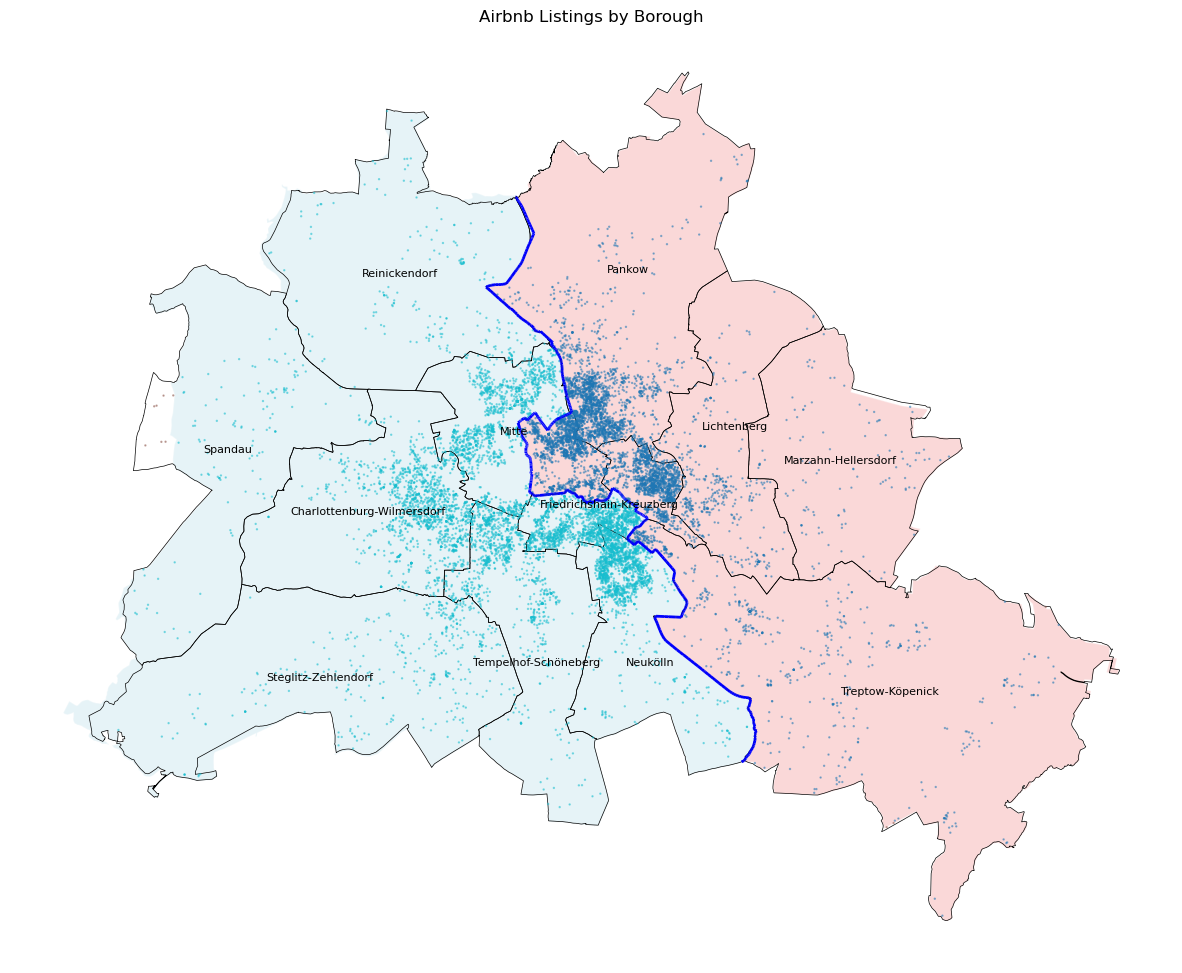

In [23]:
fig, ax = plt.subplots(figsize=(15, 15))

# Base layers
east_berlin.plot(ax=ax, facecolor='lightcoral', edgecolor='white', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='lightblue', edgecolor='white', alpha=0.3)
borough.plot(ax=ax, facecolor='none', edgecolor='black', linewidth= 0.5, alpha=1)
dividing_line_gdf.plot(ax=ax, color='blue', linewidth=2)


# Airbnb listings by borough (no legend)
airbnb_gdf.plot(ax=ax, column="region", markersize=0.5, categorical=True, legend=False, alpha = 0.5)

# Add borough names from borough GeoDataFrame
for idx, row in borough.iterrows():
    centroid = row['geometry'].centroid
    ax.text(centroid.x, centroid.y, row['Gemeinde_n'], fontsize=8,  ha='center', va='center')

plt.title("Airbnb Listings by Borough")
plt.axis("off")
plt.show()


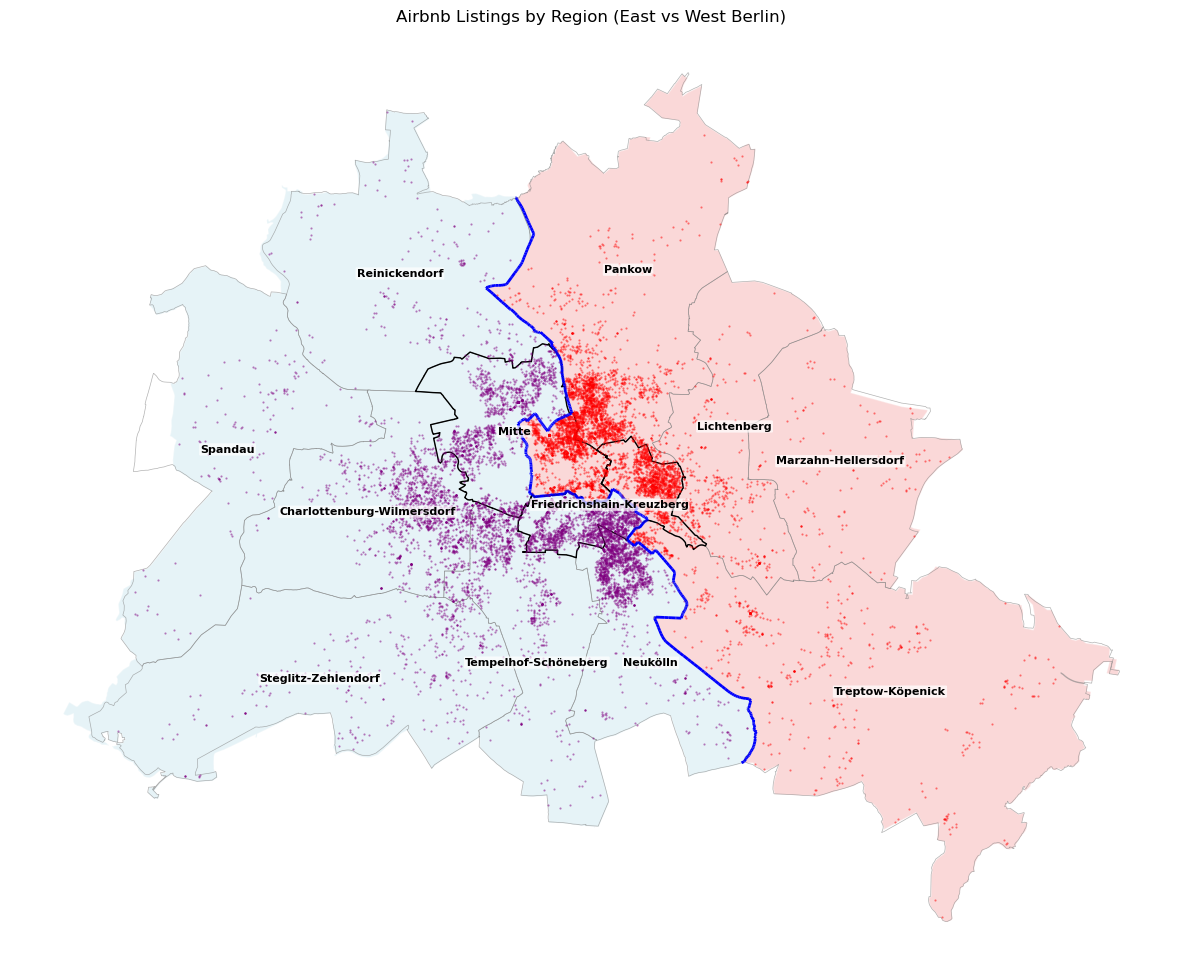

In [24]:
fig, ax = plt.subplots(figsize=(15, 15))

# Base layers
east_berlin.plot(ax=ax, facecolor='lightcoral', edgecolor='white', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='lightblue', edgecolor='white', alpha=0.3)


borough.plot(ax=ax, facecolor='none', edgecolor='grey', linewidth=0.5, alpha=0.6)

highlight_boroughs = borough[borough['Gemeinde_n'].isin(['Mitte', 'Friedrichshain-Kreuzberg'])]
highlight_boroughs.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)


# Airbnb listings by East/West
airbnb_gdf[airbnb_gdf['region'] == 'East Berlin'].plot(
    ax=ax, color='red', markersize=0.3, alpha=0.5, label='East Berlin Airbnb'
)
airbnb_gdf[airbnb_gdf['region'] == 'West Berlin'].plot(
    ax=ax, color='purple', markersize=0.3, alpha=0.5, label='West Berlin Airbnb'
)

# Dividing line
dividing_line_gdf.plot(ax=ax, color='blue', linewidth=2)

# Borough names with white background
for idx, row in borough.iterrows():
    centroid = row['geometry'].centroid
    ax.text(
        centroid.x, centroid.y, row['Gemeinde_n'],
        fontsize=8, fontweight='bold', ha='center', va='center',
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.1')
    )


plt.title("Airbnb Listings by Region (East vs West Berlin)")
plt.axis("off")

plt.savefig("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/Figures/Map_airbnb_by_region.png", dpi=300)

plt.show()


In [32]:
# listing_full = pd.read_csv(data_dir+"listings_full/listings.csv")
airbnb_gdf.head()
airbnb_gdf.to_csv("merged_airbnb.csv", index=False)

In [26]:
duplicates = airbnb_gdf[airbnb_gdf.duplicated(subset=['latitude', 'longitude', 'name'])]
print(f"Duplicates based on location and name: {len(duplicates)}")

Duplicates based on location and name: 161


In [27]:
airbnb_gdf = airbnb_gdf.drop_duplicates(subset=['latitude', 'longitude', 'name'], keep='first')


In [28]:
airbnb_gdf.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [29]:
airbnb_gdf['price'] = (
    airbnb_gdf['price']
    .astype(str)
    .str.replace(r'[$,€]', '', regex=True)
    .str.extract(r'(\d+\.?\d*)')[0]  
    .astype(float)
)

/opt/anaconda3/envs/ace-592-sae/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [30]:
# Create quantile-based price categories
airbnb_gdf['price_category'] = pd.qcut(
    airbnb_gdf['price'], 
    q=[0, 0.25, 0.5, 0.75, 1], 
    labels=['Low', 'Moderate', 'High', 'Very High']
)


/opt/anaconda3/envs/ace-592-sae/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


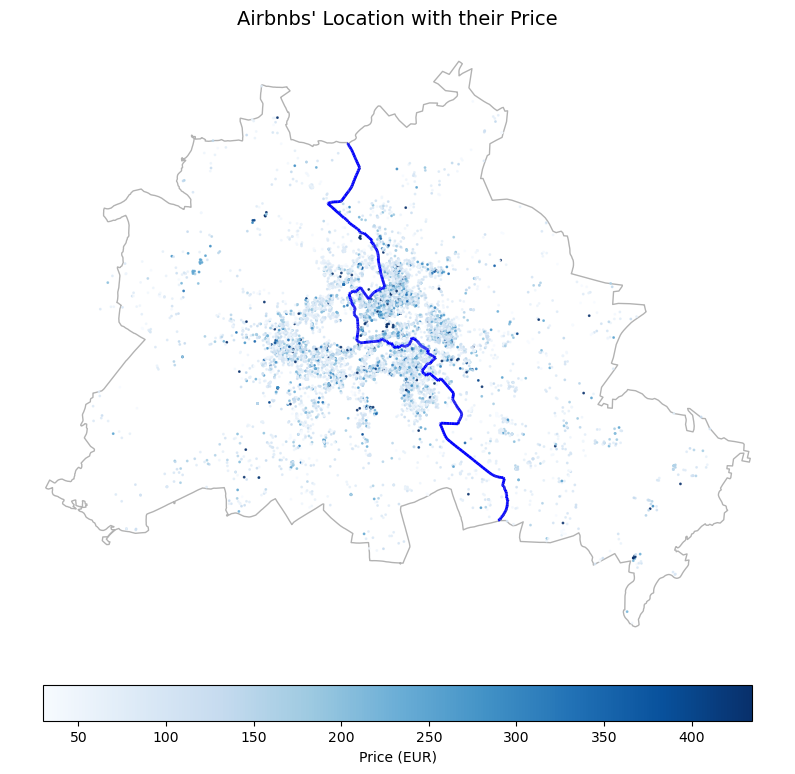

In [35]:

# filtered_gdf = airbnb_gdf[airbnb_gdf['borough'].isin(['Mitte', 'Friedrichshain'])]
# near_wall_gdf = airbnb_gdf[airbnb_gdf['distance_to_wall_m'] <= 2000]
import matplotlib as mpl 
# Set figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Base layers
east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.6)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.6)
# borough.plot(ax=ax, facecolor='none', edgecolor='black', linewidth= 0.5, alpha=1)
dividing_line_gdf.plot(ax=ax, color='blue', linewidth=2)


# Normalize price for color mapping
norm = plt.Normalize(vmin=airbnb_gdf['price'].quantile(0.02), vmax=airbnb_gdf['price'].quantile(0.98))

# Plot Airbnb listings with color based on price
airbnb_gdf.plot(
    ax=ax,
    column='price',
    cmap='Blues',  
    markersize=1,
    legend=False,
    norm=norm,
    alpha=0.8
)

sm = mpl.cm.ScalarMappable(cmap='Blues', norm=norm)
sm._A = []  # Needed in some versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Price (EUR)', fontsize=10)

ax.set_title("Airbnbs' Location with their Price", fontsize=14)
ax.axis("off")

#plt.savefig("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/Figures/Map_airbnb_by_price.png", dpi=300)

plt.show()


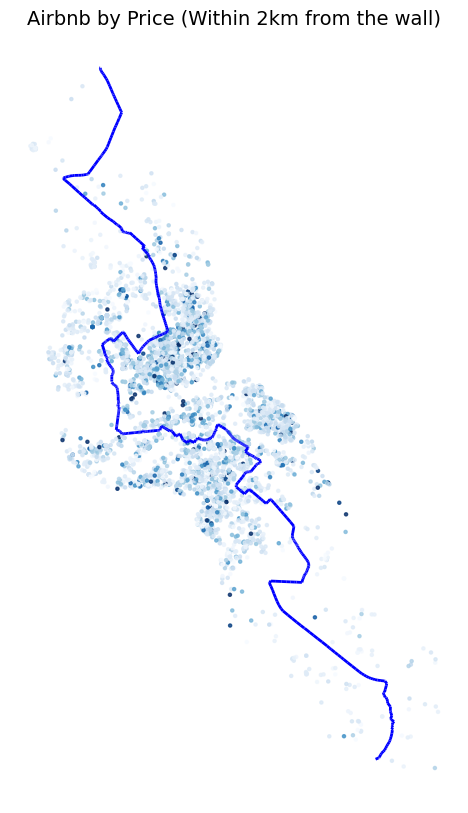

In [42]:
import matplotlib.pyplot as plt
import matplotlib as mpl
near_wall_gdf = airbnb_gdf[airbnb_gdf['distance_to_wall_m'] <= 2000]
fig, ax = plt.subplots(figsize=(10, 10))

# Base map layer
dividing_line_gdf.plot(ax=ax, color='blue', linewidth=2)

# Normalize price
norm = plt.Normalize(
    vmin=near_wall_gdf['price'].quantile(0.02),
    vmax=near_wall_gdf['price'].quantile(0.98)
)

# Plot Airbnb listings
near_wall_gdf.plot(
    ax=ax,
    column='price',
    cmap='Blues',
    markersize=5,
    legend=False,  # Avoid using GeoPandas legend
    norm=norm,
    alpha=0.8
)

ax.set_title("Airbnb by Price (Within 2km from the wall)", fontsize=14)
ax.axis("off")

#plt.savefig("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/Figures/Map_airbnb_by_price_near_wall.png", dpi=300)

plt.show()


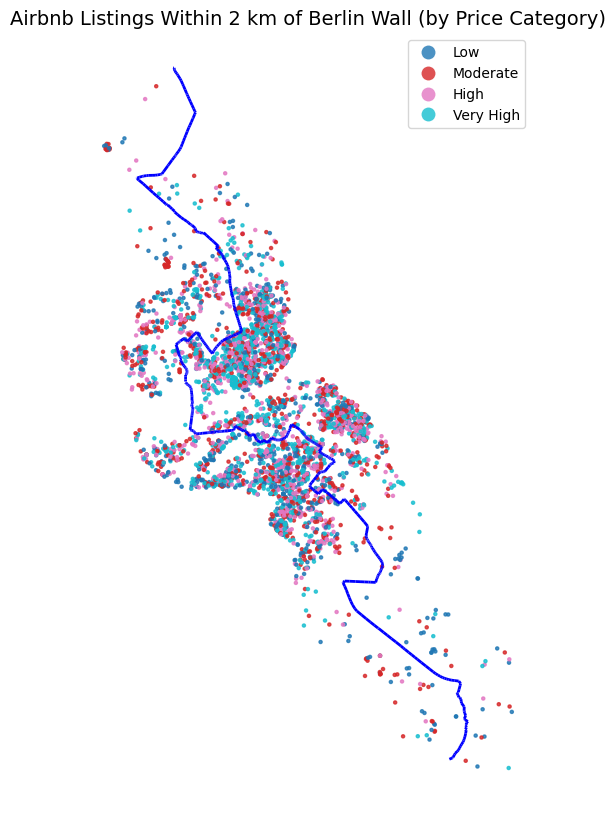

In [43]:
import matplotlib.pyplot as plt
near_wall_gdf = airbnb_gdf[airbnb_gdf['distance_to_wall_m'] <= 2000]
fig, ax = plt.subplots(figsize=(10, 10))

dividing_line_gdf.plot(ax=ax, color='blue', linewidth=2)

# Plot each category with different color
near_wall_gdf.plot(
    ax=ax,
    column='price_category',
    categorical=True,
    legend=True,
    markersize=5,
    alpha=0.8
)

ax.set_title("Airbnb Listings Within 2 km of Berlin Wall (by Price Category)", fontsize=14)
ax.axis("off")
plt.show()


In [44]:
airbnb_gdf['review_scores_value'].dtype
airbnb_gdf = airbnb_gdf[
    (airbnb_gdf['review_scores_rating'].notna()) & 
    (airbnb_gdf['review_scores_rating'] != 0)
]


In [45]:
def categorize_review(score):
    if pd.isna(score) or score < 4:
        return 'Low (<4)'
    else:
        return score  # Keep actual numeric score for gradient

airbnb_gdf['review_plot_score'] = airbnb_gdf['review_scores_rating'].apply(categorize_review)


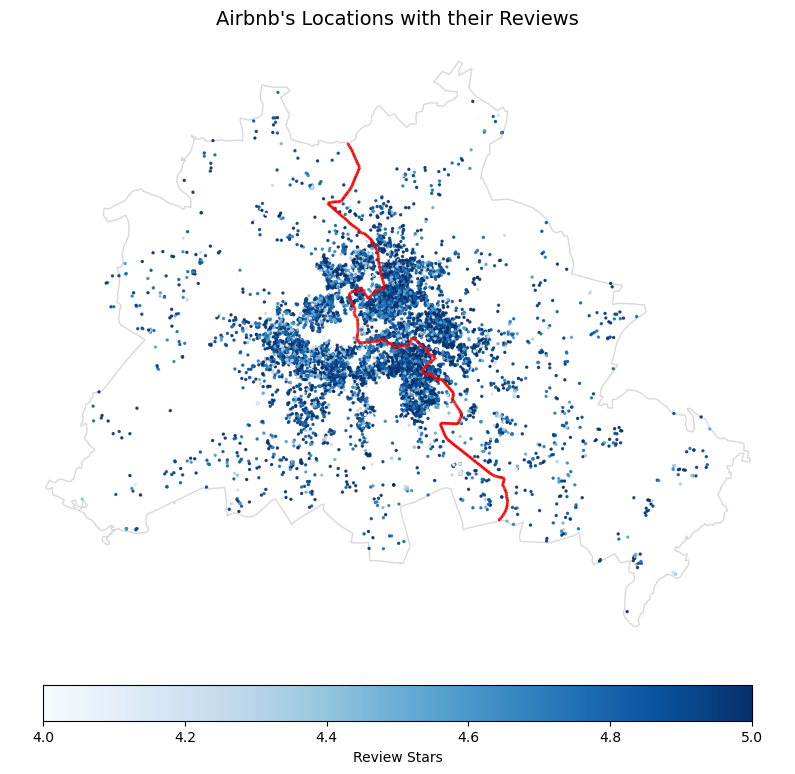

In [46]:


# Create base map
fig, ax = plt.subplots(figsize=(10, 10))

# Background
east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
dividing_line_gdf.plot(ax=ax, color='red', linewidth=2)

# Split the data
low_reviews = airbnb_gdf[airbnb_gdf['review_plot_score'] == 'Low (<4)']
good_reviews = airbnb_gdf[airbnb_gdf['review_plot_score'] != 'Low (<4)']

# Plot low scores with fixed color (e.g., red or grey)
low_reviews.plot(
    ax=ax,
    color='lightgrey',  # or 'red' if you want a warning feel
    markersize=2,
    #label='Review < 4',
    alpha=0.7
)

# Plot scores ≥ 4 with a continuous color scale
norm = plt.Normalize(vmin=4, vmax=airbnb_gdf['review_scores_value'].max())
good_reviews.plot(
    ax=ax,
    column='review_scores_rating',
    cmap='Blues',
    markersize=2,
    legend=False,
    norm=norm,
    alpha=0.85
)

sm = mpl.cm.ScalarMappable(cmap='Blues', norm=norm)
sm._A = []  # Needed in some versions of matplotlib
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Review Stars', fontsize=10)




ax.set_title("Airbnb's Locations with their Reviews", fontsize=14)
ax.axis("off")
#plt.legend()
plt.savefig("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/Figures/Map_airbnb_by_reviews.png", dpi=300)

plt.show()


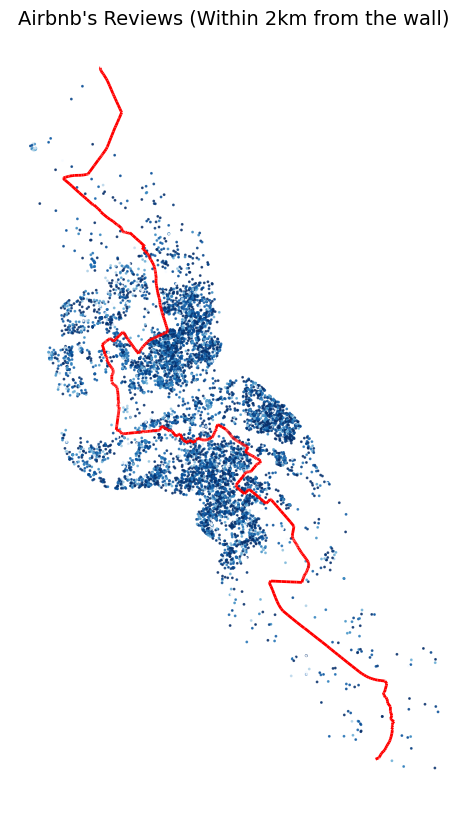

In [47]:


# filtered_gdf = airbnb_gdf[airbnb_gdf['borough'].isin(['Mitte', 'Friedrichshain'])]
near_wall_gdf = airbnb_gdf[airbnb_gdf['distance_to_wall_m'] <= 2000]

# Set figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Base layers
# east_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
# west_berlin.plot(ax=ax, facecolor='white', edgecolor='grey', alpha=0.3)
# borough.plot(ax=ax, facecolor='none', edgecolor='black', linewidth= 0.5, alpha=1)
dividing_line_gdf.plot(ax=ax, color='red', linewidth=2)


# Normalize review for color mapping
norm = plt.Normalize(vmin=near_wall_gdf['review_scores_rating'].quantile(0.02), vmax=near_wall_gdf['review_scores_rating'].max())

# Plot Airbnb listings with color based on price
near_wall_gdf.plot(
    ax=ax,
    column='review_scores_rating',
    cmap='Blues',  # reversed viridis: dark = high
    markersize=1,
    legend=False,
    norm=norm,
    alpha=0.8
)


ax.set_title("Airbnb's Reviews (Within 2km from the wall)", fontsize=14)
ax.axis("off")

plt.savefig("/Users/ard/Library/CloudStorage/Box-Box/Data Science Project/Figures/Map_airbnb_by_reviews_near_wall.png", dpi=300)

plt.show()
